# SAC baseline on Four Rooms

In [1]:
from pathlib import Path
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

# Resolve repository src path robustly when running notebook in-place.
repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / 'src').exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / 'src'))

from environments.fourrooms import FourRoomsGridWorld, FourRoomsGoalWrapper
from utils import TrajectoryReplayBuffer

DEVICE = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
print('Using device:', DEVICE)


Using device: mps


In [2]:
def make_env(goal=(9,9), slip_prob=0.00, max_horizon=500):
    base = FourRoomsGridWorld(room_size=5, max_episode_steps=max_horizon)
    env = FourRoomsGoalWrapper(
        base,
        goal_position=goal,
        goal_reward=1.0,
        step_reward=0.0,
        slip_prob=slip_prob,
    )
    return env


def evaluate_policy(env, policy_fn, episodes=8):
    returns, lengths = [], []
    for _ in range(episodes):
        obs, _ = env.reset()
        done = False
        ep_ret, ep_len = 0.0, 0
        while not done:
            act = policy_fn(obs)
            obs, rew, term, trunc, _ = env.step(act)
            ep_ret += float(rew)
            ep_len += 1
            done = term or trunc
        returns.append(ep_ret)
        lengths.append(ep_len)
    return float(np.mean(returns)), float(np.mean(lengths))


[SAC] step=  12136 | eval_return=0.000 | eval_len=500.0
[SAC] step=  75746 | eval_return=0.000 | eval_len=500.0


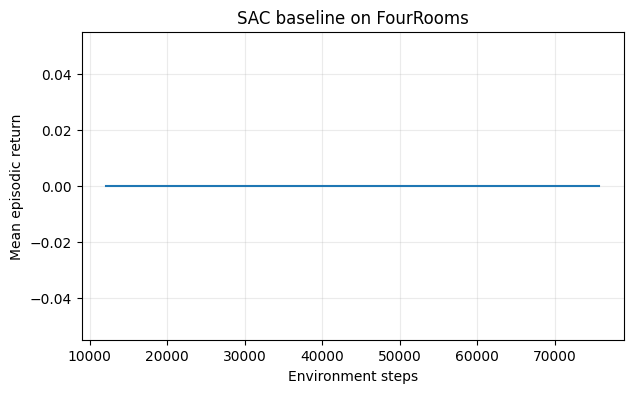

In [5]:
# ===== SAC baseline (continuous actions, twin Q) =====
class SAC_Actor(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
        )
        self.mu = nn.Linear(hidden, act_dim)
        self.log_std = nn.Linear(hidden, act_dim)

    def forward(self, obs):
        h = self.net(obs)
        mu = self.mu(h)
        log_std = torch.clamp(self.log_std(h), -5, 2)
        return mu, log_std

    def sample(self, obs):
        mu, log_std = self(obs)
        std = log_std.exp()
        dist = torch.distributions.Normal(mu, std)
        z = dist.rsample()
        a = torch.tanh(z)
        logp = dist.log_prob(z) - torch.log(1 - a.pow(2) + 1e-6)
        return a, logp.sum(-1, keepdim=True)


class SAC_Critic_Network(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim + act_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 1),
        )

    def forward(self, obs, act):
        return self.net(torch.cat([obs, act], dim=-1))


def collect_episode(env, policy_fn):
    obs, _ = env.reset()
    ep = {k: [] for k in ['obs', 'actions', 'rewards', 'next_obs', 'terminated', 'truncated']}
    done = False
    while not done:
        act = policy_fn(obs)
        next_obs, rew, term, trunc, _ = env.step(act)
        ep['obs'].append(obs.astype(np.float32))
        ep['actions'].append(act.astype(np.float32))
        ep['rewards'].append(np.float32(rew))
        ep['next_obs'].append(next_obs.astype(np.float32))
        ep['terminated'].append(np.float32(term))
        ep['truncated'].append(np.float32(trunc))
        obs = next_obs
        done = term or trunc
    return ep, len(ep['obs'])


def sac_train(total_steps=100000, warmup_steps=10000, batch_size=256, gamma=0.99, tau=0.005, lr=3e-4, alpha_lr=3e-4):
    
    env = make_env()
    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.shape[0]

    actor = SAC_Actor(obs_dim, act_dim).to(DEVICE)
    q1, q2 = SAC_Critic_Network(obs_dim, act_dim).to(DEVICE), SAC_Critic_Network(obs_dim, act_dim).to(DEVICE)
    q1_target, q2_target = SAC_Critic_Network(obs_dim, act_dim).to(DEVICE), SAC_Critic_Network(obs_dim, act_dim).to(DEVICE)


    q1_target.load_state_dict(q1.state_dict())
    q2_target.load_state_dict(q2.state_dict())

    for p in list(q1_target.parameters()) + list(q2_target.parameters()):
        p.requires_grad_(False)

    actor_opt = optim.Adam(actor.parameters(), lr=lr)
    q_opt = optim.Adam(list(q1.parameters()) + list(q2.parameters()), lr=lr)
    log_alpha = torch.tensor(np.log(0.2), dtype=torch.float32, device=DEVICE, requires_grad=True)
    alpha_opt = optim.Adam([log_alpha], lr=alpha_lr)
    target_entropy = -float(act_dim)

    replay = TrajectoryReplayBuffer(capacity=100000, obs_dim=obs_dim, action_dim=act_dim, device=DEVICE)
    total_env_steps = 0
    grad_steps = 0
    eval_returns = []

    while total_env_steps < warmup_steps:
        ep, n = collect_episode(env, lambda _: env.action_space.sample())
        replay.add_episode(ep)
        total_env_steps += n

    while total_env_steps < total_steps:
        def policy(obs):
            obs_t = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
            with torch.no_grad():
                a, _ = actor.sample(obs_t)
            return a.squeeze(0).cpu().numpy().astype(np.float32)

        ep, n = collect_episode(env, policy)
        replay.add_episode(ep)
        total_env_steps += n

        for _ in range(max(1, n // 2)):
            batch = replay.sample(batch_size)
            obs = batch.obs.float()
            act = batch.actions.float()
            rew = batch.rewards.float()
            next_obs = batch.next_obs.float()
            done = torch.clamp(batch.terminated + batch.truncated, 0, 1).float()

            with torch.no_grad():
                next_a, next_logp = actor.sample(next_obs)
                target_q = torch.min(q1_target(next_obs, next_a), q2_target(next_obs, next_a)) - log_alpha.exp() * next_logp
                y = rew + gamma * (1 - done) * target_q

            q_loss = F.mse_loss(q1(obs, act), y) + F.mse_loss(q2(obs, act), y)
            q_opt.zero_grad()
            q_loss.backward()
            q_opt.step()

            new_a, logp = actor.sample(obs)
            q_pi = torch.min(q1(obs, new_a), q2(obs, new_a))
            actor_loss = (log_alpha.exp().detach() * logp - q_pi).mean()
            actor_opt.zero_grad()
            actor_loss.backward()
            actor_opt.step()

            alpha_loss = -(log_alpha * (-logp.detach() - target_entropy)).mean()
            alpha_opt.zero_grad()
            alpha_loss.backward()
            alpha_opt.step()

            with torch.no_grad():
                for p, pt in zip(q1.parameters(), q1_target.parameters()):
                    pt.data.mul_(1 - tau).add_(tau * p.data)
                for p, pt in zip(q2.parameters(), q2_target.parameters()):
                    pt.data.mul_(1 - tau).add_(tau * p.data)

            grad_steps += 1

        if grad_steps % 200 == 0:
            eval_env = make_env()
            mean_ret, mean_len = evaluate_policy(
                eval_env,
                lambda o: torch.tanh(
                    actor(torch.tensor(o, dtype=torch.float32, device=DEVICE).unsqueeze(0))[0]
                ).squeeze(0).detach().cpu().numpy().astype(np.float32),
                episodes=8,
            )
            eval_returns.append((total_env_steps, mean_ret))
            print(f'[SAC] step={total_env_steps:7d} | eval_return={mean_ret:.3f} | eval_len={mean_len:.1f}')
            eval_env.close()

    env.close()
    return actor, eval_returns


sac_actor, sac_eval = sac_train()

if sac_eval:
    xs, ys = zip(*sac_eval)
    plt.figure(figsize=(7, 4))
    plt.plot(xs, ys)
    plt.xlabel('Environment steps')
    plt.ylabel('Mean episodic return')
    plt.title('SAC baseline on FourRooms')
    plt.grid(alpha=0.25)
    plt.show()
